In [6]:
!pip install kagglehub
!pip install librosa
!pip install torch torchaudio transformers


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import kagglehub
import os
import random
import librosa
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import matplotlib.pyplot as plt





[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Using device: cuda


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HuBERT loaded and frozen ✓
Dataset path: /home/jovyan/.cache/kagglehub/datasets/aryashah2k/noise-reduced-uaspeech-dysarthria-dataset/versions/1
Found 143290 wav files
Total  : 143290
Control (0): 69615  |  Dysarthric (1): 73675
Train: 114632  |  Val: 28658

Extracting TRAIN embeddings...
  train: 50/114632 files processed...
  train: 100/114632 files processed...
  train: 150/114632 files processed...
  train: 200/114632 files processed...
  train: 250/114632 files processed...
  train: 300/114632 files processed...
  train: 350/114632 files processed...
  train: 400/114632 files processed...
  train: 450/114632 files processed...
  train: 500/114632 files processed...
  train: 550/114632 files processed...
  train: 600/114632 files processed...
  train: 650/114632 files processed...
  train: 700/114632 files processed...
  train: 750/114632 files processed...
  train: 800/114632 files processed...
  train: 850/114632 files processed...
  train: 900/114632 files processed...
  train: 9

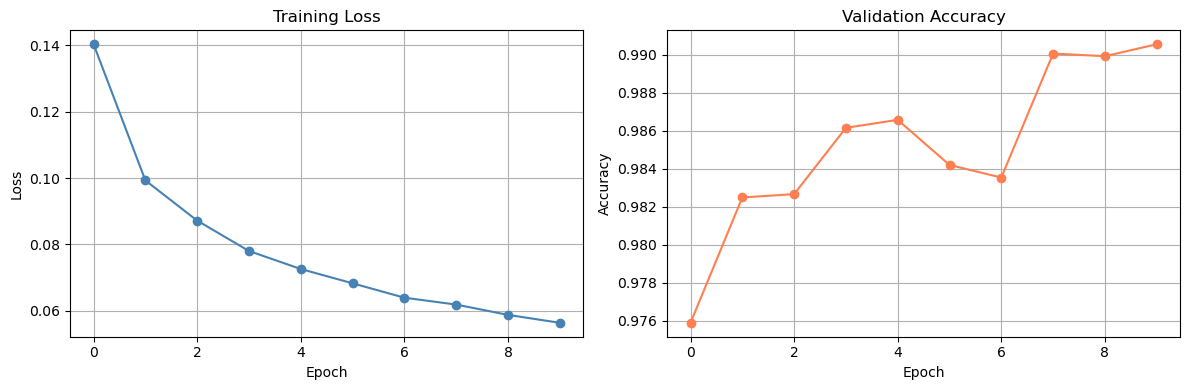

Plot saved → training_curves.png


In [8]:
# ── Cell 1: Install dependencies ─────────────────────────────────────────────
!pip install kagglehub librosa torch torchaudio transformers scikit-learn -q

# ── Cell 2: Imports ───────────────────────────────────────────────────────────
import os
import random
import numpy as np
import librosa
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from transformers import HubertModel, Wav2Vec2FeatureExtractor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ── Cell 3: Device + load HuBERT (frozen backbone) ───────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HUBERT_NAME = "facebook/hubert-base-ls960"
TARGET_SR   = 16_000
# Minimum samples HuBERT's conv stack needs to produce ≥10 time steps
# (mask_time_length=10 by default). 16 000 samples → ~49 time steps — safe.
MIN_SAMPLES = TARGET_SR          # 1 second of padding floor

print(f"Using device: {DEVICE}")

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(HUBERT_NAME)
hubert_backbone   = HubertModel.from_pretrained(HUBERT_NAME).to(DEVICE)

# Keep backbone in eval() mode at ALL times — this disables the random
# mask_time masking that caused the ValueError when sequence_length < mask_length.
hubert_backbone.eval()
for param in hubert_backbone.parameters():
    param.requires_grad = False

print("HuBERT loaded and frozen ✓")

# ── Cell 4: Download dataset ──────────────────────────────────────────────────
import kagglehub

path = kagglehub.dataset_download("aryashah2k/noise-reduced-uaspeech-dysarthria-dataset")
print("Dataset path:", path)

wav_files = []
for root, _, files in os.walk(path):
    for f in files:
        if f.endswith(".wav"):
            wav_files.append(os.path.join(root, f))

print(f"Found {len(wav_files)} wav files")

# ── Cell 5: Augmentation helpers ──────────────────────────────────────────────
def augment_waveform(y: np.ndarray, sr: int) -> np.ndarray:
    """Randomly applies prosodic augmentations to a raw waveform."""
    if random.random() < 0.5:
        rate = random.uniform(0.85, 1.15)
        y = librosa.effects.time_stretch(y, rate=rate)
    if random.random() < 0.5:
        n_steps = random.uniform(-3, 3)
        y = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)
    if random.random() < 0.5:
        gain_db = random.uniform(-6, 6)
        y = y * (10 ** (gain_db / 20))
    return y

# ── Cell 6: extract_hubert_features ──────────────────────────────────────────
def extract_hubert_features(path: str, augment: bool = False) -> torch.Tensor:
    """
    Loads a wav file, optionally augments it, and returns a (768,) embedding
    produced by mean-pooling HuBERT's last hidden states over time.

    Key fixes vs. original:
    - Pads audio to MIN_SAMPLES so HuBERT always sees ≥10 time steps
      (avoids: ValueError mask_length > sequence_length).
    - Calls hubert_backbone in torch.no_grad() — no gradients needed here.
    - backbone stays in .eval() mode — masking is disabled.
    """
    y, sr = librosa.load(path, sr=TARGET_SR, mono=True)

    if augment:
        y = augment_waveform(y, sr)

    # ── FIX: enforce minimum length ──────────────────────────────────────────
    if len(y) < MIN_SAMPLES:
        y = np.pad(y, (0, MIN_SAMPLES - len(y)))

    # Normalise amplitude to [-1, 1]
    max_val = np.abs(y).max()
    if max_val > 0:
        y = y / max_val

    inputs = feature_extractor(
        y,
        sampling_rate=TARGET_SR,
        return_tensors="pt",
        padding=True,
    )
    input_values = inputs.input_values.to(DEVICE)   # (1, T)

    with torch.no_grad():
        # ── FIX: hubert_backbone is already in .eval(); pass explicitly ─────
        outputs = hubert_backbone(input_values)      # last_hidden_state: (1, T', 768)

    # Mean-pool over time → (768,)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze(0).cpu()
    return embedding

# ── Cell 7: Build labels ──────────────────────────────────────────────────────
file_list, labels = [], []
for f in wav_files:
    file_list.append(f)
    labels.append(0 if "control" in f.lower() else 1)

print(f"Total  : {len(file_list)}")
print(f"Control (0): {labels.count(0)}  |  Dysarthric (1): {labels.count(1)}")

# ── Cell 8: Train / val split ─────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    file_list, labels, test_size=0.2, random_state=42, stratify=labels
)
print(f"Train: {len(X_train)}  |  Val: {len(X_val)}")

# ── Cell 9: Pre-compute HuBERT embeddings (runs once per session) ─────────────
# Pre-computing means:
#   • HuBERT runs only ONCE per file instead of once per epoch → huge speedup.
#   • DataLoader workers never touch the GPU → no CUDA fork errors.

def precompute_embeddings(file_list, labels, augment=False, desc=""):
    embeddings, all_labels = [], []
    n = len(file_list)
    for i, (path, label) in enumerate(zip(file_list, labels)):
        emb = extract_hubert_features(path, augment=augment)
        embeddings.append(emb)
        all_labels.append(label)
        if (i + 1) % 50 == 0 or (i + 1) == n:
            print(f"  {desc}: {i+1}/{n} files processed...")
    return torch.stack(embeddings), torch.tensor(all_labels, dtype=torch.long)

print("\nExtracting TRAIN embeddings...")
X_train_emb, y_train_t = precompute_embeddings(X_train, y_train, augment=True,  desc="train")

print("\nExtracting VAL embeddings...")
X_val_emb,   y_val_t   = precompute_embeddings(X_val,   y_val,   augment=False, desc="val")

print("\nEmbedding shapes:")
print(f"  X_train_emb : {X_train_emb.shape}")   # (N_train, 768)
print(f"  X_val_emb   : {X_val_emb.shape}")     # (N_val,   768)

# ── Cell 10: DataLoaders (TensorDataset — no file I/O, no GPU fork issues) ────
train_loader = DataLoader(
    TensorDataset(X_train_emb, y_train_t), batch_size=16, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val_emb, y_val_t), batch_size=16, shuffle=False
)

# ── Cell 11: Classifier head ──────────────────────────────────────────────────
class HubertClassifier(nn.Module):
    """
    Lightweight MLP head trained on top of frozen HuBERT embeddings.
    Input : (batch, 768)
    Output: (batch, 2)
    """
    def __init__(self, input_dim=768, hidden_dim=256, num_classes=2, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):   # x: (batch, 768) — pre-computed embeddings
        return self.net(x)

model     = HubertClassifier().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print(model)

# ── Cell 12: Training loop ────────────────────────────────────────────────────
NUM_EPOCHS     = 10
train_losses   = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):

    # --- Train ---
    model.train()
    total_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)   # x: (batch, 768)
        preds = model(x)
        loss  = criterion(preds, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # --- Validate ---
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            preds = model(x)
            correct += (preds.argmax(1) == y).sum().item()
            total   += y.size(0)

    val_acc = correct / total
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1:>2}/{NUM_EPOCHS} | "
          f"Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2%}")

# ── Cell 13: Plot ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses,   marker='o', color='steelblue')
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)

ax2.plot(val_accuracies, marker='o', color='coral')
ax2.set_title("Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Plot saved → training_curves.png")